# Ghost Lengths and Induced Transfers

When we observe a gene tree reconciled with a species tree, we typically only have access to a **sampled** subset of all species.
The unsampled ("ghost") species still affect the reconciliation: transfers may have involved ghost species, and branches of the sampled tree carry hidden evolutionary time from ghost lineages.

This notebook demonstrates how to:
1. Simulate a complete species tree and gene trees
2. Sample a subset of species leaves
3. Compute **ghost lengths** — the hidden evolutionary time on each branch of the sampled tree
4. Compute **induced transfers** — how transfers project from the complete tree onto the sampled tree
5. Visualize everything with NodeMark coloring

## 1. Setup: simulate a species tree and gene tree

In [2]:
import rustree
import pandas as pd

# Simulate a species tree with 20 extant species (no extinction for simplicity)
species_tree = rustree.simulate_species_tree(n=20, lambda_=1.0, mu=0.0, seed=42)
print(f"Species tree: {species_tree.num_nodes()} nodes, {species_tree.num_leaves()} leaves")
print(f"Leaf names: {species_tree.leaf_names()}")

Species tree: 39 nodes, 20 leaves
Leaf names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']


In [3]:
# Simulate a gene tree with transfers only (no duplication, no loss)
# This makes it easier to see what happens with induced transfers
gene_tree = species_tree.simulate_dtl(
    lambda_d=0.0,   # no duplication
    lambda_t=0.5,   # transfer rate
    lambda_l=0.0,   # no loss
    seed=12
)
print(f"Gene tree: {gene_tree.num_nodes()} nodes, {gene_tree.num_extant()} extant")
print(f"Events: {gene_tree.count_events()}")

Gene tree: 63 nodes, 32 extant
Events: {'duplications': 0, 'losses': 0, 'leaves': 32, 'speciations': 23, 'transfers': 8}


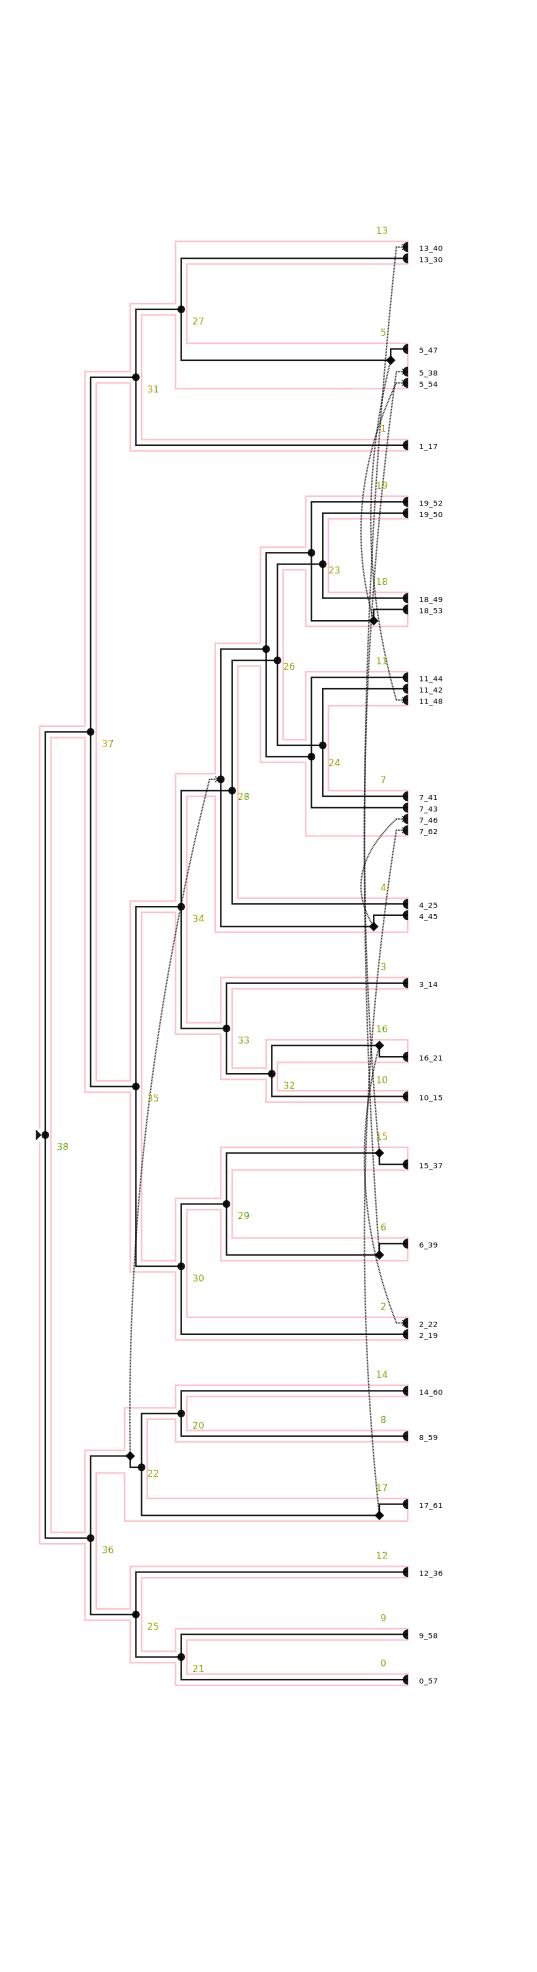

In [4]:
# Visualize the complete reconciled tree
gene_tree.display(
    gene_colors="black",
    internal_species_names=True,
    gene_thickness=2,
    species_thickness=2,
    background="white",
)

In [5]:
gene_tree.transfers()

,node_id,name,parent,left_child,left_child_name,right_child,right_child_name,length,depth,species_node,species_node_left,species_node_right,event
0,6,22_6,1,11,22_11,12,28_12,0.480291,2.854830,22,22,28,Transfer
1,16,16_16,13,21,16_21,22,2_22,0.369202,3.353132,16,16,2,Transfer
2,23,6_23,20,39,6_39,40,13_40,0.222920,3.587714,6,6,13,Transfer
3,24,15_24,20,37,15_37,38,5_38,0.177831,3.542626,15,15,5,Transfer
4,27,4_27,12,45,4_45,46,7_46,0.327865,3.695552,4,4,7,Transfer
5,29,5_29,18,47,5_47,48,11_48,0.303333,3.737078,5,5,11,Transfer
6,51,18_51,34,53,18_53,54,5_54,0.037115,3.832627,18,18,5,Transfer
7,55,17_55,11,61,17_61,62,7_62,0.084200,3.918263,17,17,7,Transfer


## 2. Sample species leaves

In practice, we never observe all species. We sample a subset of extant species.
`sample_leaf_names` uniformly samples species names. You can specify either a count (`n`) or a fraction.

In [6]:
# Sample 10 out of 20 species by count
sampled_names = species_tree.sample_leaf_names(n=10, seed=42)
print(f"Sampled {len(sampled_names)} species: {sampled_names}")

Sampled 10 species: ['1', '6', '3', '7', '13', '10', '16', '11', '14', '12']


In [7]:
# Or sample by fraction (50% of leaves)
sampled_half = species_tree.sample_leaf_names(fraction=0.5, seed=99)
print(f"Sampled {len(sampled_half)} species (50%): {sampled_half}")

Sampled 10 species (50%): ['11', '8', '5', '3', '12', '17', '18', '2', '16', '6']


### Visualize which species are sampled

When `sampled_species_names` is passed to `display()`, species tree nodes are colored by their **NodeMark**:
- **Keep** (green): nodes present in the sampled tree (sampled leaves + their MRCAs)
- **HasDescendant** (orange): internal nodes with exactly one side having sampled descendants (collapsed in the sampled tree)
- **Discard** (red): nodes with no sampled descendants

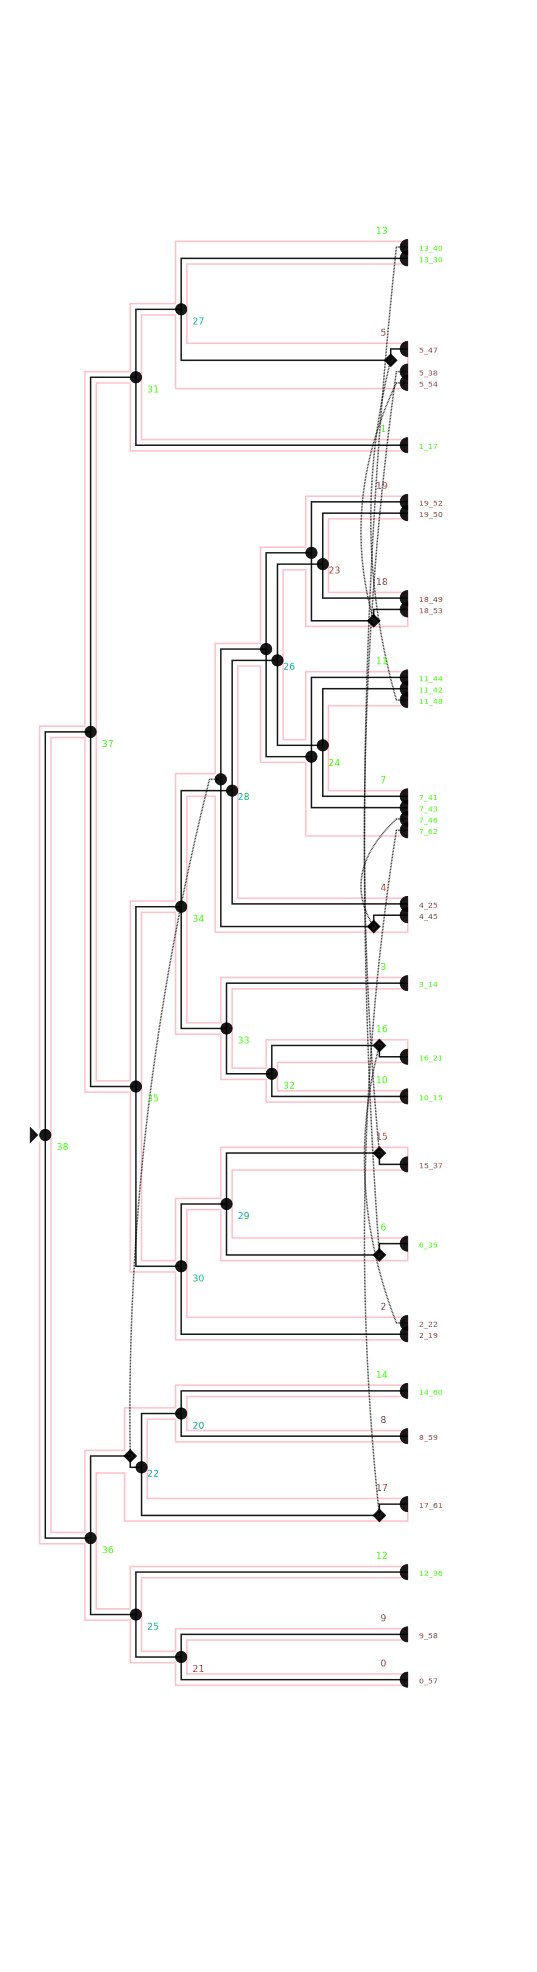

In [8]:
gene_tree.display(
    sampled_species_names=sampled_names,
    gene_colors="black",
    keep_color="#3CFF00",
    has_descendant_color="#00B4FF",
    discard_color="#FF4444",
    gene_thickness=2,
    species_thickness=2,
    symbol_size=10,
    background="white",
    internal_species_names=True,
)

### Color transfer arrows and gene nodes by NodeMark

When `sampled_species_names` is provided, gene node labels are automatically colored by the NodeMark of the species they map to.
Adding `color_transfers_by` also colors transfer arrows based on the **recipient** or **donor** species' NodeMark.

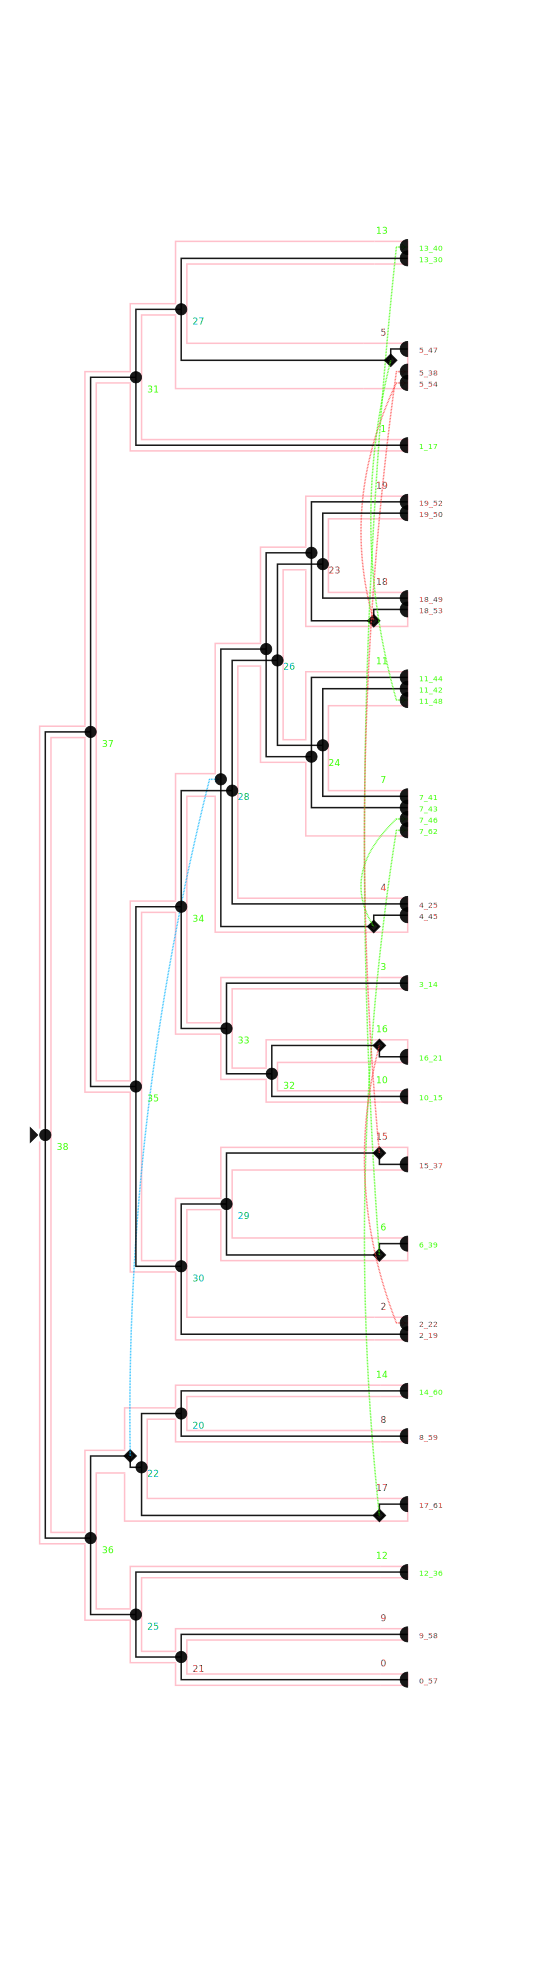

In [9]:
# Species names, gene names, and transfer arrows all colored by NodeMark
gene_tree.display(
    sampled_species_names=sampled_names,
    color_transfers_by="recipient",
    gene_colors="black",
    keep_color="#3CFF00",
    has_descendant_color="#00B4FF",
    discard_color="#FF4444",
    gene_thickness=2,
    species_thickness=2,
    symbol_size=10,
    background="white",
    internal_species_names=True,
)

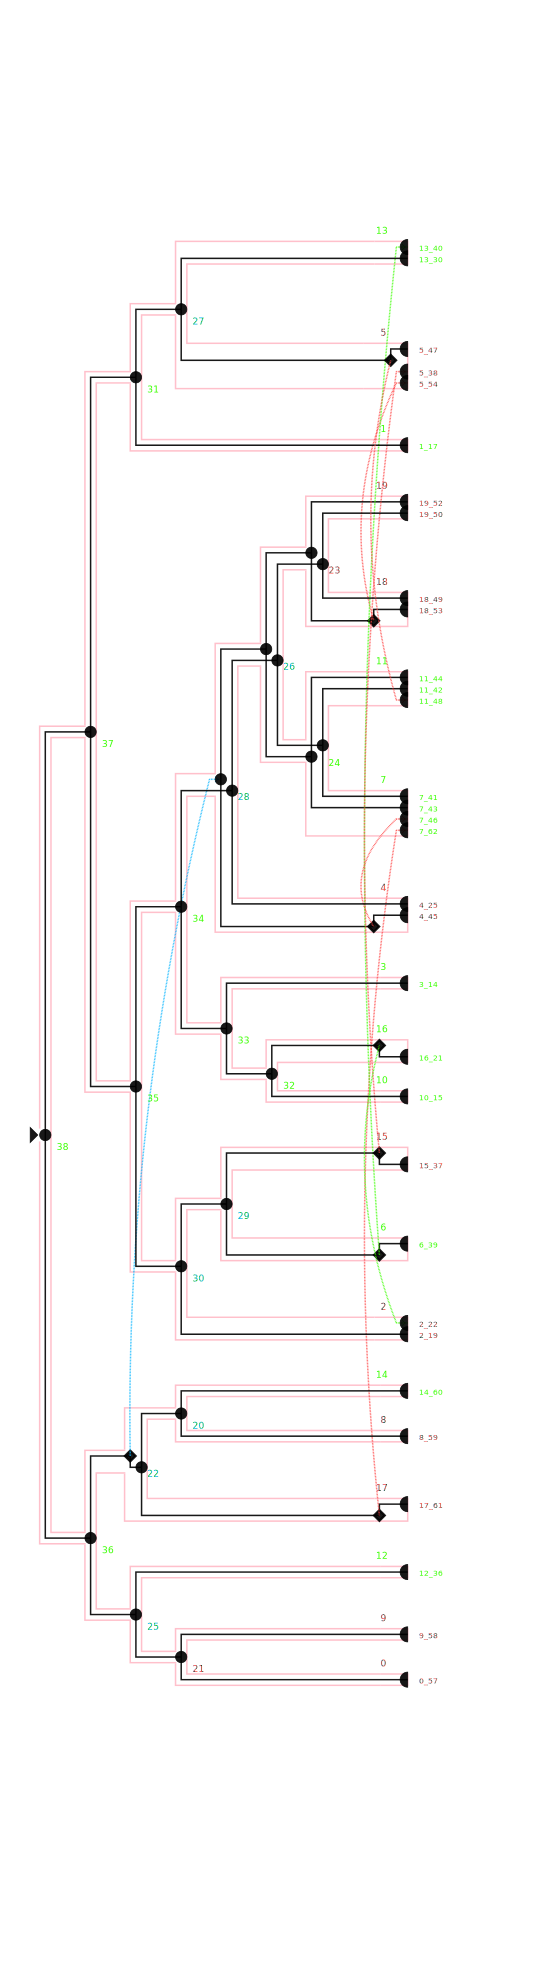

In [10]:
# Same but with transfer arrows colored by donor
gene_tree.display(
    sampled_species_names=sampled_names,
    color_transfers_by="donor",
    gene_colors="black",
    keep_color="#3CFF00",
    has_descendant_color="#00B4FF",
    discard_color="#FF4444",
    gene_thickness=2,
    species_thickness=2,
    symbol_size=10,
    background="white",
    internal_species_names=True,
)

## 3. Ghost lengths

When we remove unsampled species, the sampled tree's branches are shorter than the "true" evolutionary time.
The **ghost length** of a sampled-tree branch is the total branch length of all non-sampled (ghost) nodes
in the complete tree that project onto that branch.

Intuitively: ghost length measures the hidden evolutionary time on each branch due to unsampled lineages.

`species_tree.compute_ghost_lengths(sampled_leaf_names)` returns a DataFrame with one row per node in the sampled tree.

In [11]:
ghost_df = species_tree.compute_ghost_lengths(sampled_names)
ghost_df

,node_index,node_name,ghost_length
0,0,38,0.000000
1,1,36,0.000000
2,2,12,1.593084
3,3,14,1.645303
4,4,37,0.000000
5,5,35,0.000000
6,6,6,1.929975
7,7,34,0.000000
8,8,33,0.000000
9,9,32,0.000000


In [12]:
# Which branches have ghost length > 0?
# These are the branches where unsampled species "hide"
has_ghost = ghost_df[ghost_df["ghost_length"] > 0]
print(f"{len(has_ghost)} out of {len(ghost_df)} branches have ghost length > 0")
print()
has_ghost

5 out of 19 branches have ghost length > 0



,node_index,node_name,ghost_length
2,2,12,1.593084
3,3,14,1.645303
6,6,6,1.929975
13,13,24,1.859499
18,18,13,0.668064


In [13]:
# Compare total branch length: sampled tree vs ghost contribution
sampled_tree = species_tree.extract_induced_subtree_by_names(sampled_names)

sampled_length = sum(node.length for node in sampled_tree)
ghost_total = ghost_df["ghost_length"].sum()
complete_length = sum(node.length for node in species_tree)

print(f"Complete tree total branch length: {complete_length:.4f}")
print(f"Sampled tree total branch length:  {sampled_length:.4f}")
print(f"Total ghost length:                {ghost_total:.4f}")
print(f"Sampled + ghost:                   {sampled_length + ghost_total:.4f}")
print()
print(f"Ghost fraction: {ghost_total / complete_length:.1%} of total evolutionary time is hidden")

Complete tree total branch length: 18.1460
Sampled tree total branch length:  14.7810
Total ghost length:                7.6959
Sampled + ghost:                   22.4770

Ghost fraction: 42.4% of total evolutionary time is hidden


### Ghost lengths depend on sampling intensity

The fewer species we sample, the more ghost length we accumulate.

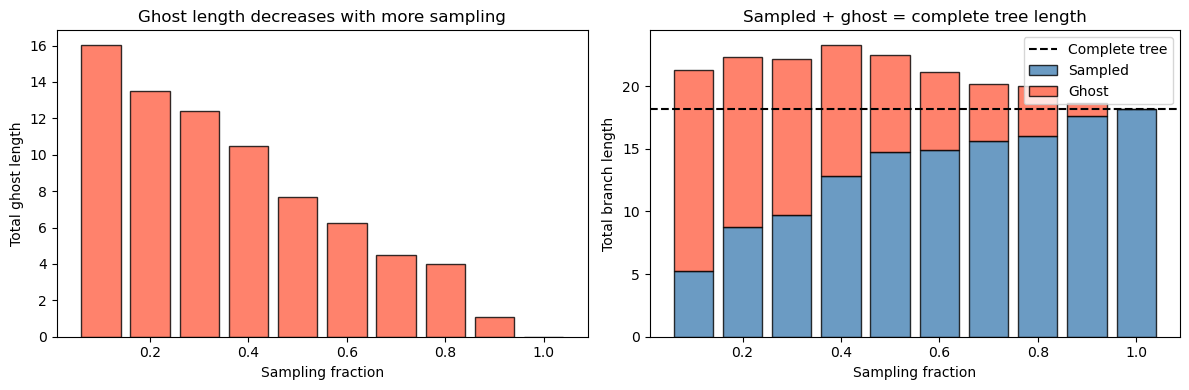

In [14]:
import matplotlib.pyplot as plt

fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ghost_totals = []
sampled_totals = []

for frac in fractions:
    names = species_tree.sample_leaf_names(fraction=frac, seed=42)
    gdf = species_tree.compute_ghost_lengths(names)
    stree = species_tree.extract_induced_subtree_by_names(names)
    
    ghost_totals.append(gdf["ghost_length"].sum())
    sampled_totals.append(sum(node.length for node in stree))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(fractions, ghost_totals, width=0.08, color="tomato", edgecolor="black", alpha=0.8)
ax1.set_xlabel("Sampling fraction")
ax1.set_ylabel("Total ghost length")
ax1.set_title("Ghost length decreases with more sampling")

ax2.bar(fractions, sampled_totals, width=0.08, color="steelblue", edgecolor="black", alpha=0.8, label="Sampled")
ax2.bar(fractions, ghost_totals, width=0.08, bottom=sampled_totals, color="tomato", edgecolor="black", alpha=0.8, label="Ghost")
ax2.axhline(y=complete_length, color="black", linestyle="--", label="Complete tree")
ax2.set_xlabel("Sampling fraction")
ax2.set_ylabel("Total branch length")
ax2.set_title("Sampled + ghost = complete tree length")
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Induced transfers

A transfer event in the complete tree goes from species A to species B. But if A and/or B are not in the sampled tree,
the transfer still happened — it just projects onto the nearest sampled branches.

The **induced transfer** maps each complete-tree transfer to the corresponding branches in the sampled tree.

`gene_tree.compute_induced_transfers(sampled_leaf_names)` returns a DataFrame with columns:
- `time` — when the transfer occurred
- `gene_id` — gene node index involved
- `from_species_complete`, `to_species_complete` — donor/recipient in the complete tree
- `from_species_sampled`, `to_species_sampled` — donor/recipient projected onto the sampled tree

In [15]:
# First, let's see which transfers occurred in the complete tree
events_df = gene_tree.to_csv()
transfers = events_df[events_df["event"] == "Transfer"]
print(f"Total transfers in gene tree: {len(transfers)}")
transfers[["node_id", "name", "species_node", "species_node_left", "species_node_right"]]

Total transfers in gene tree: 8


,node_id,name,species_node,species_node_left,species_node_right
6,6,22_6,22,22,28
16,16,16_16,16,16,2
23,23,6_23,6,6,13
24,24,15_24,15,15,5
27,27,4_27,4,4,7
29,29,5_29,5,5,11
51,51,18_51,18,18,5
55,55,17_55,17,17,7


In [16]:
# Compute induced transfers
induced_df = gene_tree.compute_induced_transfers(sampled_names)
print(f"Induced transfers: {len(induced_df)}")
induced_df

Induced transfers: 8


,time,gene_id,from_species_complete,to_species_complete,from_species_sampled,to_species_sampled
0,2.854830,6,22,28,3,13
1,3.353132,16,16,2,11,6
2,3.542626,24,15,5,6,18
3,3.587714,23,6,13,6,18
4,3.695552,27,4,7,13,14
5,3.737078,29,5,11,18,15
6,3.832627,51,18,5,13,18
7,3.918263,55,17,7,3,14


Each row shows:
- The **complete** donor/recipient (which may be ghost species)
- The **sampled** donor/recipient (the nearest sampled branch the transfer projects onto)

When `from_species_sampled == to_species_sampled`, the transfer becomes invisible in the sampled tree —
both donor and recipient project onto the same branch.

In [17]:
# Check for invisible transfers (same sampled donor and recipient)
invisible = induced_df[induced_df["from_species_sampled"] == induced_df["to_species_sampled"]]
visible = induced_df[induced_df["from_species_sampled"] != induced_df["to_species_sampled"]]

print(f"Visible induced transfers: {len(visible)}")
print(f"Invisible transfers (donor = recipient in sampled tree): {len(invisible)}")

if len(invisible) > 0:
    print("\nInvisible transfers:")
    display(invisible)

Visible induced transfers: 8
Invisible transfers (donor = recipient in sampled tree): 0


### How sampling affects the number of visible transfers

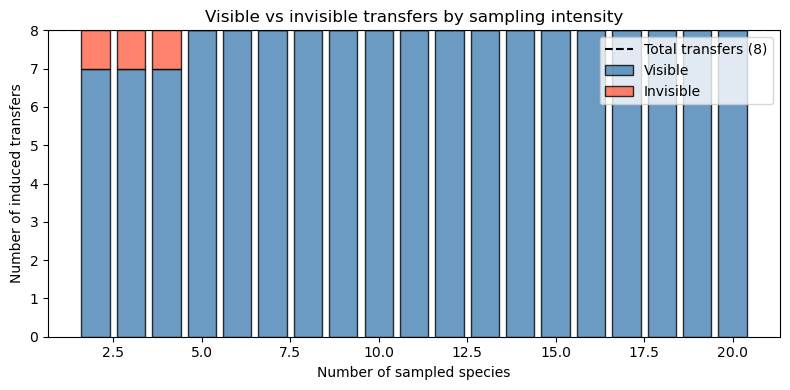

In [18]:
n_total_transfers = len(transfers)
sample_sizes = list(range(2, 21))
n_visible = []
n_invisible = []

for k in sample_sizes:
    names = species_tree.sample_leaf_names(n=k, seed=42)
    idf = gene_tree.compute_induced_transfers(names)
    vis = len(idf[idf["from_species_sampled"] != idf["to_species_sampled"]])
    n_visible.append(vis)
    n_invisible.append(len(idf) - vis)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sample_sizes, n_visible, color="steelblue", edgecolor="black", alpha=0.8, label="Visible")
ax.bar(sample_sizes, n_invisible, bottom=n_visible, color="tomato", edgecolor="black", alpha=0.8, label="Invisible")
ax.axhline(y=n_total_transfers, color="black", linestyle="--", label=f"Total transfers ({n_total_transfers})")
ax.set_xlabel("Number of sampled species")
ax.set_ylabel("Number of induced transfers")
ax.set_title("Visible vs invisible transfers by sampling intensity")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Pruning gene trees by species

When we sample species, we should also prune the gene tree to only include genes from sampled species.
`sample_by_species_names` keeps only gene leaves whose species (extracted from the gene name via `speciesName_geneId` convention) is in the list.

In [19]:
gene_tree.count_events()

{'speciations': 23,
 'transfers': 8,
 'losses': 0,
 'leaves': 32,
 'duplications': 0}

In [20]:
gene_tree.duplications()

,node_id,name,parent,left_child,left_child_name,right_child,right_child_name,length,depth,species_node,species_node_left,species_node_right,event


In [21]:
# Prune gene tree to sampled species
pruned_gene = gene_tree.sample_by_species_names(sampled_names[:3])

print(f"Full gene tree:   {gene_tree.num_nodes()} nodes, {gene_tree.num_extant()} extant genes")
print(f"Pruned gene tree: {pruned_gene.num_nodes()} nodes, {pruned_gene.num_extant()} extant genes")
print()
print(f"Full events:   {gene_tree.count_events()}")
print(f"Pruned events: {pruned_gene.count_events()}")

Full gene tree:   63 nodes, 32 extant genes
Pruned gene tree: 5 nodes, 3 extant genes

Full events:   {'leaves': 32, 'transfers': 8, 'speciations': 23, 'duplications': 0, 'losses': 0}
Pruned events: {'transfers': 0, 'speciations': 2, 'losses': 0, 'leaves': 3, 'duplications': 0}


In [22]:
sampled_names[:5]

['1', '6', '3', '7', '13']

In [23]:
pruned_gene.to_newick()

'((6_39:1.312465,3_14:1.312465)35_3:0.552272,1_17:1.864737)37_2:2.062216;'

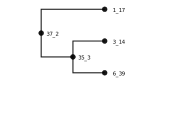

In [24]:
# Visualize the pruned gene tree
pruned_gene.display(
    gene_colors="black",
    internal_species_names=True,
    internal_gene_names=True,
    gene_thickness=2,
    species_thickness=2,
    background="white",
    gene_only=True,
)

## 6. Complete pipeline

Putting it all together: simulate, sample, compute ghost lengths and induced transfers.

In [25]:
# Step 1: Simulate species tree
species_tree = rustree.simulate_species_tree(n=30, lambda_=1.0, mu=0.0, seed=7)

# Step 2: Simulate gene tree with transfers
gene_tree = species_tree.simulate_dtl(
    lambda_d=0.05,
    lambda_t=0.15,
    lambda_l=0.02,
    seed=42
)
print(f"Gene tree events: {gene_tree.count_events()}")

# Step 3: Sample 10 species
sampled_names = species_tree.sample_leaf_names(n=10, seed=1)
print(f"Sampled species: {sampled_names}")

# Step 4: Compute ghost lengths
ghost_df = species_tree.compute_ghost_lengths(sampled_names)
print(f"\nGhost lengths (non-zero branches):")
display(ghost_df[ghost_df["ghost_length"] > 0])

# Step 5: Compute induced transfers
induced_df = gene_tree.compute_induced_transfers(sampled_names)
print(f"\nInduced transfers ({len(induced_df)} total):")
display(induced_df)

# Step 6: Prune gene tree
pruned_gene = gene_tree.sample_by_species_names(sampled_names)
print(f"\nPruned gene tree: {pruned_gene.num_extant()} extant genes")

Gene tree events: {'leaves': 33, 'speciations': 29, 'transfers': 3, 'duplications': 1, 'losses': 1}
Sampled species: ['17', '27', '21', '18', '16', '10', '5', '4', '7', '15']

Ghost lengths (non-zero branches):


,node_index,node_name,ghost_length
3,3,17,1.712505
8,8,54,5.396692
9,9,47,8.537865
15,15,30,2.664652
18,18,18,3.619952



Induced transfers (3 total):


,time,gene_id,from_species_complete,to_species_complete,from_species_sampled,to_species_sampled
0,2.559939,22,34,3,4,9
1,3.038211,13,20,0,9,9
2,3.256059,50,24,22,15,18



Pruned gene tree: 10 extant genes


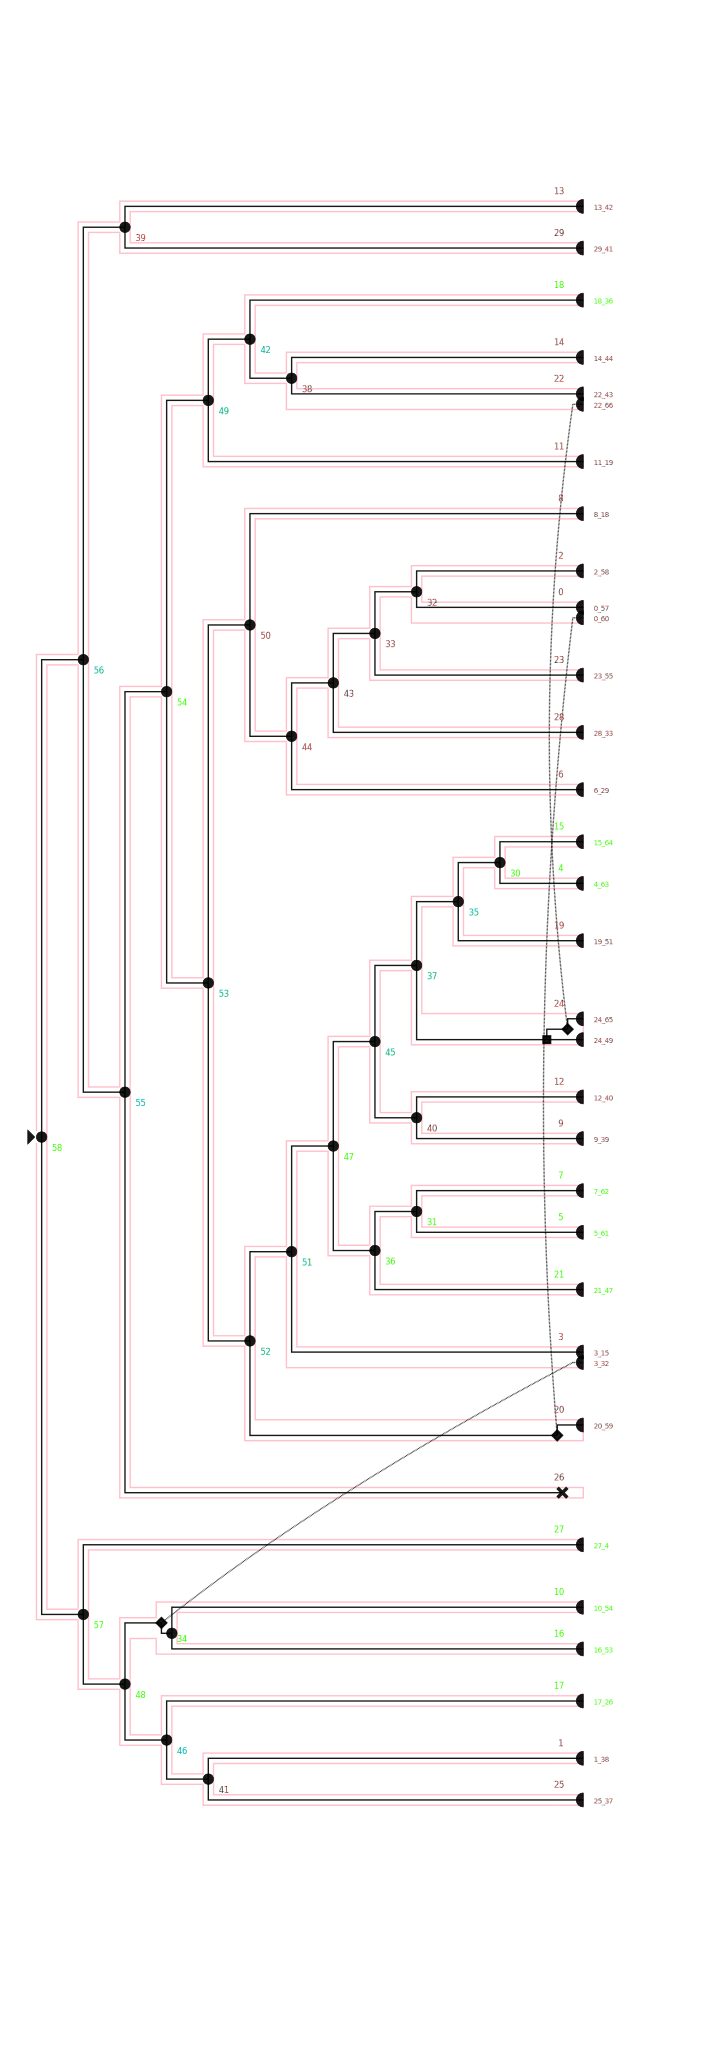

In [26]:
# Visualize with NodeMark coloring
gene_tree.display(
    sampled_species_names=sampled_names,
    gene_colors="black",
    keep_color="#3CFF00",
    has_descendant_color="#00B4FF",
    discard_color="#FF4444",
    gene_thickness=2,
    species_thickness=2,
    symbol_size=10,
    background="white",
    internal_species_names=True,
)

## 7. Batch analysis: ghost lengths and transfers across many gene families

In a real study, you would simulate many gene families and analyze the distribution of ghost lengths and induced transfers.

In [27]:
species_tree = rustree.simulate_species_tree(n=50, lambda_=1.0, mu=0.0, seed=42)
sampled_names = species_tree.sample_leaf_names(n=20, seed=42)

# Simulate 500 gene families
gene_trees = species_tree.simulate_dtl_batch(
    n=500,
    lambda_d=0.05,
    lambda_t=0.2,
    lambda_l=0.05,
    seed=123,
)

# Compute induced transfers for each gene family
total_transfers = []
visible_transfers = []
invisible_transfers = []

for gt in gene_trees:
    idf = gt.compute_induced_transfers(sampled_names)
    total = len(idf)
    vis = len(idf[idf["from_species_sampled"] != idf["to_species_sampled"]])
    total_transfers.append(total)
    visible_transfers.append(vis)
    invisible_transfers.append(total - vis)

print(f"Mean total transfers per gene: {sum(total_transfers)/len(total_transfers):.2f}")
print(f"Mean visible transfers:        {sum(visible_transfers)/len(visible_transfers):.2f}")
print(f"Mean invisible transfers:      {sum(invisible_transfers)/len(invisible_transfers):.2f}")
print(f"Mean fraction visible:         {sum(v/t if t > 0 else 1 for v, t in zip(visible_transfers, total_transfers))/len(total_transfers):.1%}")

Mean total transfers per gene: 18.95
Mean visible transfers:        18.00
Mean invisible transfers:      0.95
Mean fraction visible:         95.3%


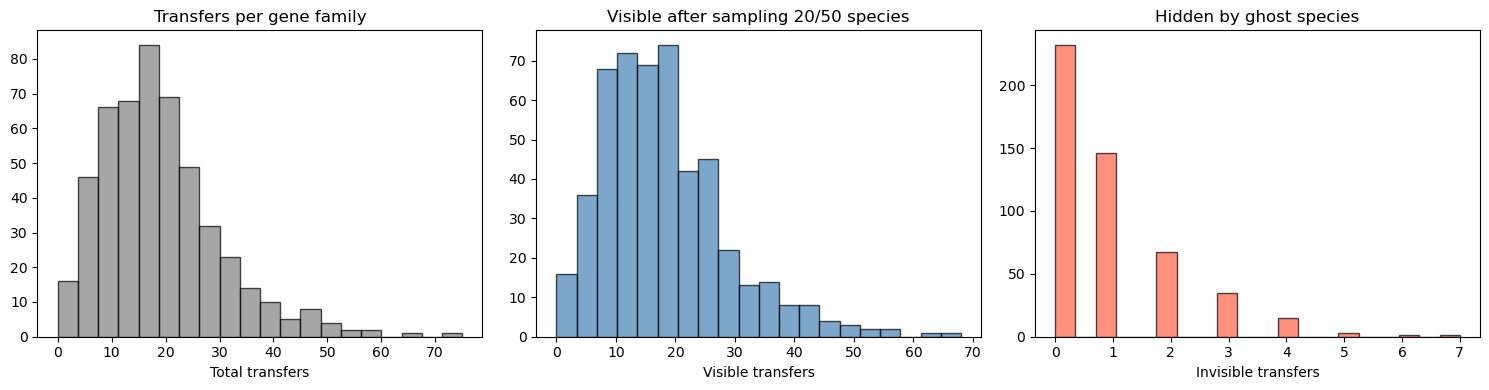

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(total_transfers, bins=20, edgecolor="black", alpha=0.7, color="grey")
axes[0].set_xlabel("Total transfers")
axes[0].set_title("Transfers per gene family")

axes[1].hist(visible_transfers, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].set_xlabel("Visible transfers")
axes[1].set_title("Visible after sampling 20/50 species")

axes[2].hist(invisible_transfers, bins=20, edgecolor="black", alpha=0.7, color="tomato")
axes[2].set_xlabel("Invisible transfers")
axes[2].set_title("Hidden by ghost species")

plt.tight_layout()
plt.show()

### Ghost length distribution across the sampled tree

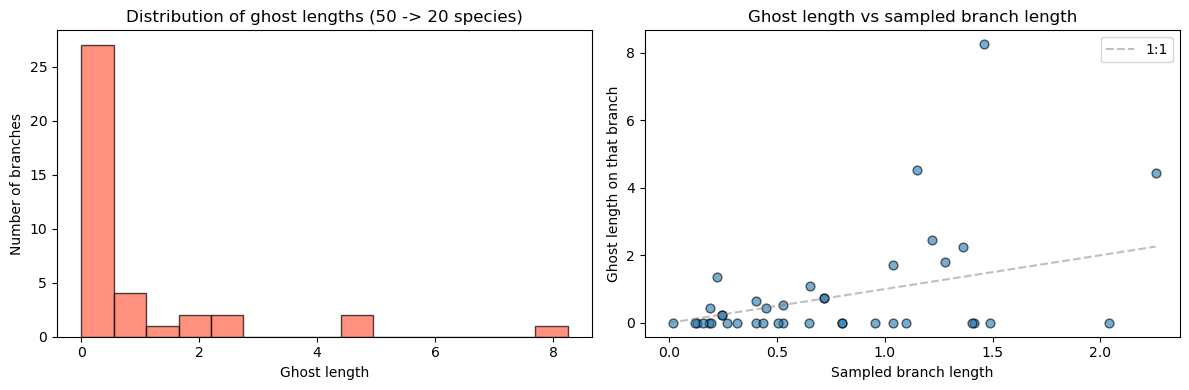

In [29]:
ghost_df = species_tree.compute_ghost_lengths(sampled_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of ghost lengths
ax1.hist(ghost_df["ghost_length"], bins=15, edgecolor="black", alpha=0.7, color="tomato")
ax1.set_xlabel("Ghost length")
ax1.set_ylabel("Number of branches")
ax1.set_title("Distribution of ghost lengths (50 -> 20 species)")

# Ghost length vs branch position (leaves vs internal)
sampled_tree = species_tree.extract_induced_subtree_by_names(sampled_names)
sampled_lengths = [node.length for node in sampled_tree]
ghost_lengths = ghost_df["ghost_length"].tolist()

ax2.scatter(sampled_lengths, ghost_lengths, alpha=0.6, edgecolor="black", s=40)
ax2.set_xlabel("Sampled branch length")
ax2.set_ylabel("Ghost length on that branch")
ax2.set_title("Ghost length vs sampled branch length")
ax2.plot([0, max(sampled_lengths)], [0, max(sampled_lengths)], "--", color="grey", alpha=0.5, label="1:1")
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Sampling sweep: how many species do we need?

Run the same gene tree against different sampling fractions and track how ghost lengths and transfer visibility change.

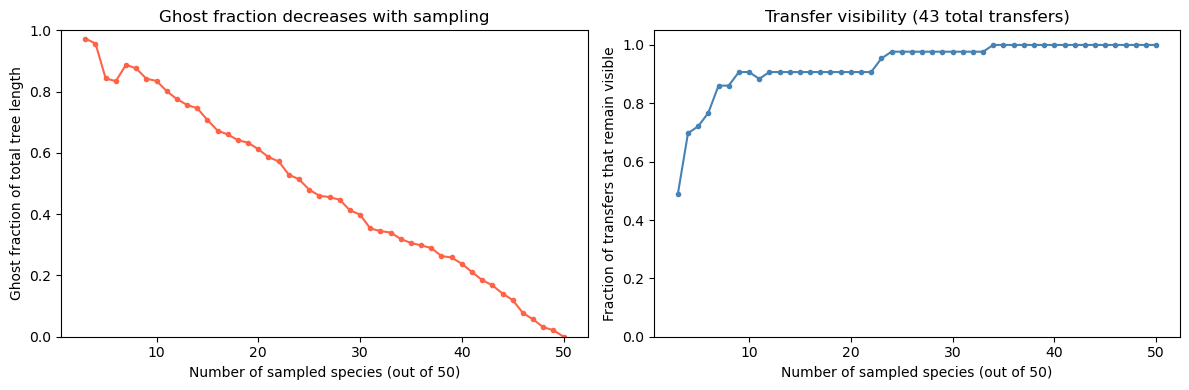

In [30]:
species_tree = rustree.simulate_species_tree(n=50, lambda_=1.0, mu=0.0, seed=42)
gene_tree = species_tree.simulate_dtl(0.05, 0.3, 0.05, seed=42)

n_transfers_total = gene_tree.count_events()["transfers"]
complete_length = sum(node.length for node in species_tree)

sample_sizes = list(range(3, 51))
ghost_fracs = []
visible_fracs = []

for k in sample_sizes:
    names = species_tree.sample_leaf_names(n=k, seed=42)
    
    # Ghost lengths
    gdf = species_tree.compute_ghost_lengths(names)
    ghost_fracs.append(gdf["ghost_length"].sum() / complete_length)
    
    # Induced transfers
    idf = gene_tree.compute_induced_transfers(names)
    if len(idf) > 0:
        vis = len(idf[idf["from_species_sampled"] != idf["to_species_sampled"]])
        visible_fracs.append(vis / len(idf))
    else:
        visible_fracs.append(1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sample_sizes, ghost_fracs, "o-", color="tomato", markersize=3)
ax1.set_xlabel("Number of sampled species (out of 50)")
ax1.set_ylabel("Ghost fraction of total tree length")
ax1.set_title("Ghost fraction decreases with sampling")
ax1.set_ylim(0, 1)

ax2.plot(sample_sizes, visible_fracs, "o-", color="steelblue", markersize=3)
ax2.set_xlabel("Number of sampled species (out of 50)")
ax2.set_ylabel("Fraction of transfers that remain visible")
ax2.set_title(f"Transfer visibility ({n_transfers_total} total transfers)")
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 9. Multiple gene families: aggregating induced transfers

Concatenate induced transfers from many gene families to identify species pairs that frequently exchange genes.

In [31]:
species_tree = rustree.simulate_species_tree(n=30, lambda_=1.0, mu=0.0, seed=42)
sampled_names = species_tree.sample_leaf_names(n=15, seed=42)

gene_trees = species_tree.simulate_dtl_batch(
    n=200,
    lambda_d=0.05, lambda_t=0.2, lambda_l=0.05,
    seed=42
)

# Collect all induced transfers across gene families
all_induced = []
for i, gt in enumerate(gene_trees):
    idf = gt.compute_induced_transfers(sampled_names)
    if len(idf) > 0:
        idf = idf.copy()
        idf["gene_family"] = i
        all_induced.append(idf)

if all_induced:
    combined = pd.concat(all_induced, ignore_index=True)
    
    # Filter to visible transfers only
    visible = combined[combined["from_species_sampled"] != combined["to_species_sampled"]]
    
    print(f"Total induced transfers across {len(gene_trees)} families: {len(combined)}")
    print(f"Visible transfers: {len(visible)}")
    print(f"\nTop transfer highways (sampled tree branch pairs):")
    
    highways = (
        visible
        .groupby(["from_species_sampled", "to_species_sampled"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(highways.head(10))

Total induced transfers across 200 families: 2908
Visible transfers: 2626

Top transfer highways (sampled tree branch pairs):


,from_species_sampled,to_species_sampled,count
358,28,3,114
46,3,28,86
356,28,1,85
23,2,28,78
0,1,28,68
357,28,2,63
89,6,28,63
27,3,6,59
24,3,2,57
71,6,3,48


## API Reference

### `species_tree.sample_leaf_names(n=None, fraction=None, seed=None)`
Uniformly sample species leaf names. Provide exactly one of `n` (count) or `fraction` (0.0–1.0).

### `species_tree.compute_ghost_lengths(sampled_leaf_names)`
Returns a DataFrame with columns:
- `node_index` — index in the sampled tree
- `node_name` — name of the sampled-tree node
- `ghost_length` — total branch length of ghost (non-sampled) species projecting onto this branch

### `gene_tree.compute_induced_transfers(sampled_leaf_names)`
Returns a DataFrame with columns:
- `time` — time of the transfer event
- `gene_id` — gene node index
- `from_species_complete` — donor species index in the complete tree
- `to_species_complete` — recipient species index in the complete tree
- `from_species_sampled` — donor projected onto the sampled tree
- `to_species_sampled` — recipient projected onto the sampled tree

### `gene_tree.sample_by_species_names(species_names)`
Prune the gene tree to keep only genes from the specified species. Species are extracted from gene names using the `speciesName_geneId` naming convention.

### `gene_tree.display(sampled_species_names=..., keep_color=..., has_descendant_color=..., discard_color=...)`
Visualize the reconciled tree with species nodes colored by NodeMark.

## 10. Full inference pipeline: simulate, prune, reconcile with AleRax, and correlate ghost lengths with inferred transfers

This pipeline demonstrates the full workflow:
1. Simulate a species tree and DTL gene families
2. Sample species and prune both species and gene trees
3. Reconcile the pruned gene trees with the pruned species tree using **AleRax**
4. Aggregate inferred transfer events per species branch
5. Compute ghost lengths and scatter-plot them against the number of donated transfers per branch

Species tree: 30 leaves, 59 nodes
Simulated: GeneForest(species_leaves=30, gene_trees=100)
Sampled 20 species: ['4', '16', '17', '26', '20', '29', '15', '5', '21', '1', '22', '13', '12', '23', '10', '0', '27', '11', '6', '3']
Reconciled 100 gene families

Transfer events (mean across AleRax samples, summed over families):
  Total source->dest pairs: 317
  Total donated transfers: 158.4


Running ALERax: "alerax" "-s" "/tmp/.tmpvqIlwS/input/species_tree.newick" "-f" "/tmp/.tmpvqIlwS/input/families.txt" "-p" "/tmp/.tmpvqIlwS/alerax_output" "--model-parametrization" "PER-FAMILY" "--gene-tree-samples" "100" "--seed" "42"


,total_donated
source,
27,24.32
3,12.62
17,8.08
46,8.03
32,8.02
0,8.01
43,6.98
11,6.45
37,6.43


Ghost lengths per branch of the pruned species tree:


,node_index,node_name,ghost_length
0,0,58,0.000000
1,1,56,0.000000
2,2,55,0.000000
3,3,54,0.000000
4,4,52,0.000000
5,5,0,2.185584
6,6,50,0.000000
7,7,32,0.000000
8,8,26,0.000000
9,9,13,0.000000


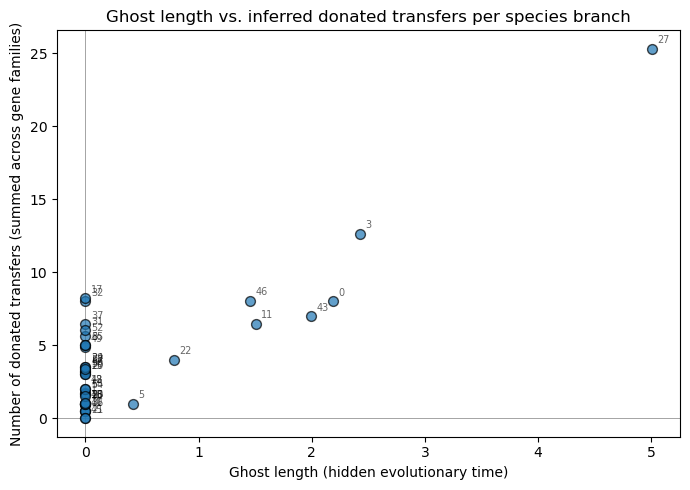


Correlation: 0.855


In [32]:
import rustree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. Simulate a birth-death species tree ----------
species_tree = rustree.simulate_species_tree(n=30, lambda_=1.0, mu=0.0, seed=42)
print(f"Species tree: {species_tree.num_leaves()} leaves, {species_tree.num_nodes()} nodes")

# ---------- 2. Simulate DTL gene families (returns a GeneForest) ----------
forest = species_tree.simulate_dtl_batch(
    n=100,
    lambda_d=0.0,
    lambda_t=0.05,
    lambda_l=0.0,
    require_extant=True,
    seed=123,
)
print(f"Simulated: {forest}")

# ---------- 3. Sample species, prune, and reconcile ----------
sampled_names = species_tree.sample_leaf_names(n=20, seed=42)
print(f"Sampled {len(sampled_names)} species: {sampled_names}")

# sample_extant() removes loss nodes, sample_leaves() prunes to sampled species
result = (
    forest
    .sample_extant()
    .sample_leaves(sampled_names)
    .reconcile_with_alerax(num_samples=100, seed=42)
)
print(f"Reconciled {len(result.family_results)} gene families")

# ---------- 4. Node renaming is handled automatically by the AleRax bindings ----------

# ---------- 5. Transfer events ----------
# Aggregate mean donated transfers per species branch across all gene families
donated_per_species = {}
for family_name, res in result.family_results.items():
    for species_name, counts in res.statistics.events_per_species.items():
        donated_per_species[species_name] = (
            donated_per_species.get(species_name, 0.0) + counts.transfers
        )

# Also collect the detailed source->destination transfer DataFrame
all_transfer_dfs = []
for family_name, res in result.family_results.items():
    tf = res.statistics.transfers_df()
    tf["family"] = family_name
    all_transfer_dfs.append(tf)
transfer_df = pd.concat(all_transfer_dfs, ignore_index=True)
print(f"\nTransfer events (mean across AleRax samples, summed over families):")
print(f"  Total source->dest pairs: {len(transfer_df)}")
print(f"  Total donated transfers: {transfer_df['mean_count'].sum():.1f}")
display(
    transfer_df.groupby("source")["mean_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("total_donated")
)

# ---------- 6. Ghost lengths ----------
ghost_df = species_tree.compute_ghost_lengths(sampled_names)
print("Ghost lengths per branch of the pruned species tree:")
display(ghost_df)

# ---------- 7. Scatter plot: donated transfers vs ghost length ----------
# Build a merged table: one row per pruned-tree branch
donated_series = pd.Series(donated_per_species, name="donated_transfers")
merged = ghost_df.set_index("node_name").join(donated_series).fillna(0).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    merged["ghost_length"],
    merged["donated_transfers"],
    s=50, edgecolor="black", alpha=0.7, zorder=3,
)
# Label points
for _, row in merged.iterrows():
    ax.annotate(
        row["node_name"],
        (row["ghost_length"], row["donated_transfers"]),
        fontsize=7, alpha=0.6,
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_xlabel("Ghost length (hidden evolutionary time)")
ax.set_ylabel("Number of donated transfers (summed across gene families)")
ax.set_title("Ghost length vs. inferred donated transfers per species branch")
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nCorrelation: {merged['ghost_length'].corr(merged['donated_transfers']):.3f}")

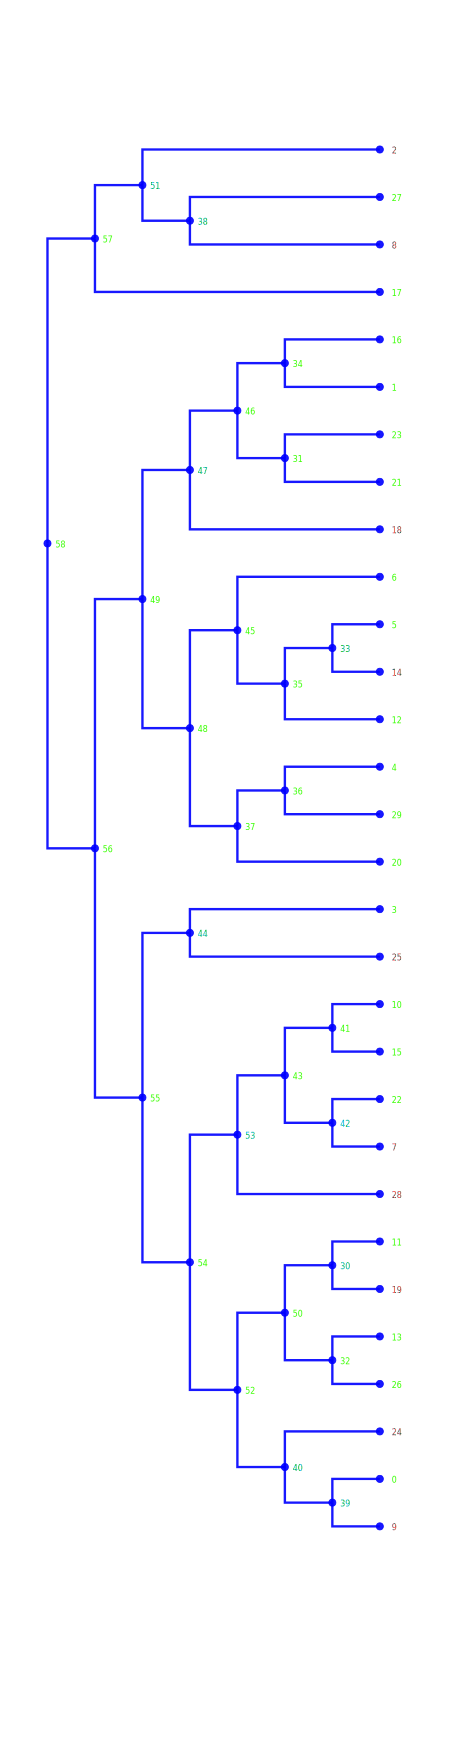

In [33]:
species_tree.display(
    sampled_species_names=sampled_names,
    keep_color="#3CFF00",
    has_descendant_color="#00B4FF",
    discard_color="#FF4444",
    background="white",
)

In [34]:
gene_trees

GeneForest(species_leaves=30, gene_trees=200)